# Abe 2008 finite-beam fringes for BaMgF4

This notebook follows the layout of `test_braun1997.ipynb` and evaluates the six BMF geometries used for d31, d32, d33 (two cuts), d15, and d24. The plate thickness is initially fixed to 2 mm.

Unlike the scalar SiC example, the 45-degree d15/d24 configurations propagate both fundamental s and p modes. Their complex fields are transformed to crystal coordinates and contracted with the full 3x6 d tensor before the SH Green-function projection.

In [5]:
from dataclasses import replace
from pathlib import Path
from types import SimpleNamespace
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'test_codes':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from fitting_strategies.abe2008 import Abe2008FiniteBeamModel, bmf_parameters
from fitting_strategies.braun1997 import Braun1997Strategy

plt.rcParams.update({'figure.figsize': (10, 5), 'axes.grid': True})

## 1. Common scan settings and BMF geometries

`BEAM_DIAMETER_UM` follows the metadata convention used in `test_braun1997`; the Abe model converts it to the field radius a. The scan uses a 0.1-degree grid. Plate thickness is stored separately in every configuration so measured values can be substituted independently.

In [6]:
WAVELENGTH_NM = 1064.0
BEAM_DIAMETER_UM = 400.0
THETA_DEG = np.linspace(-20.0, 20.0, 401)
MAX_M = 4
X_POINTS = 161
Z_POINTS = 601
WORKERS = 4

BMF_CONFIGS = [
    dict(label='d31', d_component='d_31', crystal_orientation='010', rotation_axis='100', pol_in=0, pol_out=90, thickness_mm=0.768),
    dict(label='d32', d_component='d_32', crystal_orientation='100', rotation_axis='010', pol_in=0, pol_out=90, thickness_mm=1.384),
    dict(label='d33, cut 100', d_component='d_33', crystal_orientation='100', rotation_axis='001', pol_in=0, pol_out=0, thickness_mm=3.824),
    dict(label='d33, cut 010', d_component='d_33', crystal_orientation='010', rotation_axis='001', pol_in=0, pol_out=0, thickness_mm=2.0),
    dict(label='d15', d_component='d_15', crystal_orientation='010', rotation_axis='100', pol_in=45, pol_out=0, thickness_mm=2.0),
    dict(label='d24', d_component='d_24', crystal_orientation='100', rotation_axis='010', pol_in=45, pol_out=0, thickness_mm=1.384),
]
pd.DataFrame(BMF_CONFIGS)

,label,d_component,crystal_orientation,rotation_axis,pol_in,pol_out,thickness_mm
0,d31,d_31,010,100,0,90,0.768
1,d32,d_32,100,010,0,90,1.384
2,"d33, cut 100",d_33,100,001,0,0,3.824
3,"d33, cut 010",d_33,010,001,0,0,2.000
4,d15,d_15,010,100,45,0,2.000
5,d24,d_24,100,010,45,0,1.384


In [7]:
def make_parameters(config, *, single_path=False, **updates):
    reflection_updates = {}
    if single_path:
        reflection_updates = dict(
            include_fundamental_reflections=False,
            include_sh_reflections=False,
            max_fundamental_round_trips=0,
            max_sh_round_trips=0,
        )
    else:
        reflection_updates = dict(
            max_fundamental_round_trips=MAX_M,
            max_sh_round_trips=MAX_M,
        )
    numerical_updates = dict(x_points=X_POINTS, z_points=Z_POINTS)
    numerical_updates.update(reflection_updates)
    numerical_updates.update(updates)
    return bmf_parameters(
        d_component=config['d_component'],
        crystal_orientation=config['crystal_orientation'],
        rotation_axis=config['rotation_axis'],
        input_polarization_deg=config['pol_in'],
        detected_polarization_deg=config['pol_out'],
        wavelength_nm=WAVELENGTH_NM,
        thickness_mm=config['thickness_mm'],
        beam_diameter_um=BEAM_DIAMETER_UM,
        **numerical_updates,
    )


def normalized(values, reference=None):
    values = np.asarray(values, dtype=float)
    scale = np.nanmax(values if reference is None else reference)
    return values / scale if np.isfinite(scale) and scale > 0 else np.zeros_like(values)

## 2. Calculate all six finite-beam multiple-reflection fringes

In [8]:
abe_curves = {}
started = time.perf_counter()
for config in BMF_CONFIGS:
    params = make_parameters(config)
    curve = Abe2008FiniteBeamModel(params).power(THETA_DEG, workers=WORKERS)
    abe_curves[config['label']] = curve
    print(f"{config['label']:13s}: max={np.max(curve):.6g}")
print(f'total calculation time: {time.perf_counter() - started:.1f} s')

d31          : max=1.38739e+08
d32          : max=12478.9
d33, cut 100 : max=26711.6
d33, cut 010 : max=25496.6
d15          : max=12019.1
d24          : max=473386
total calculation time: 277.8 s


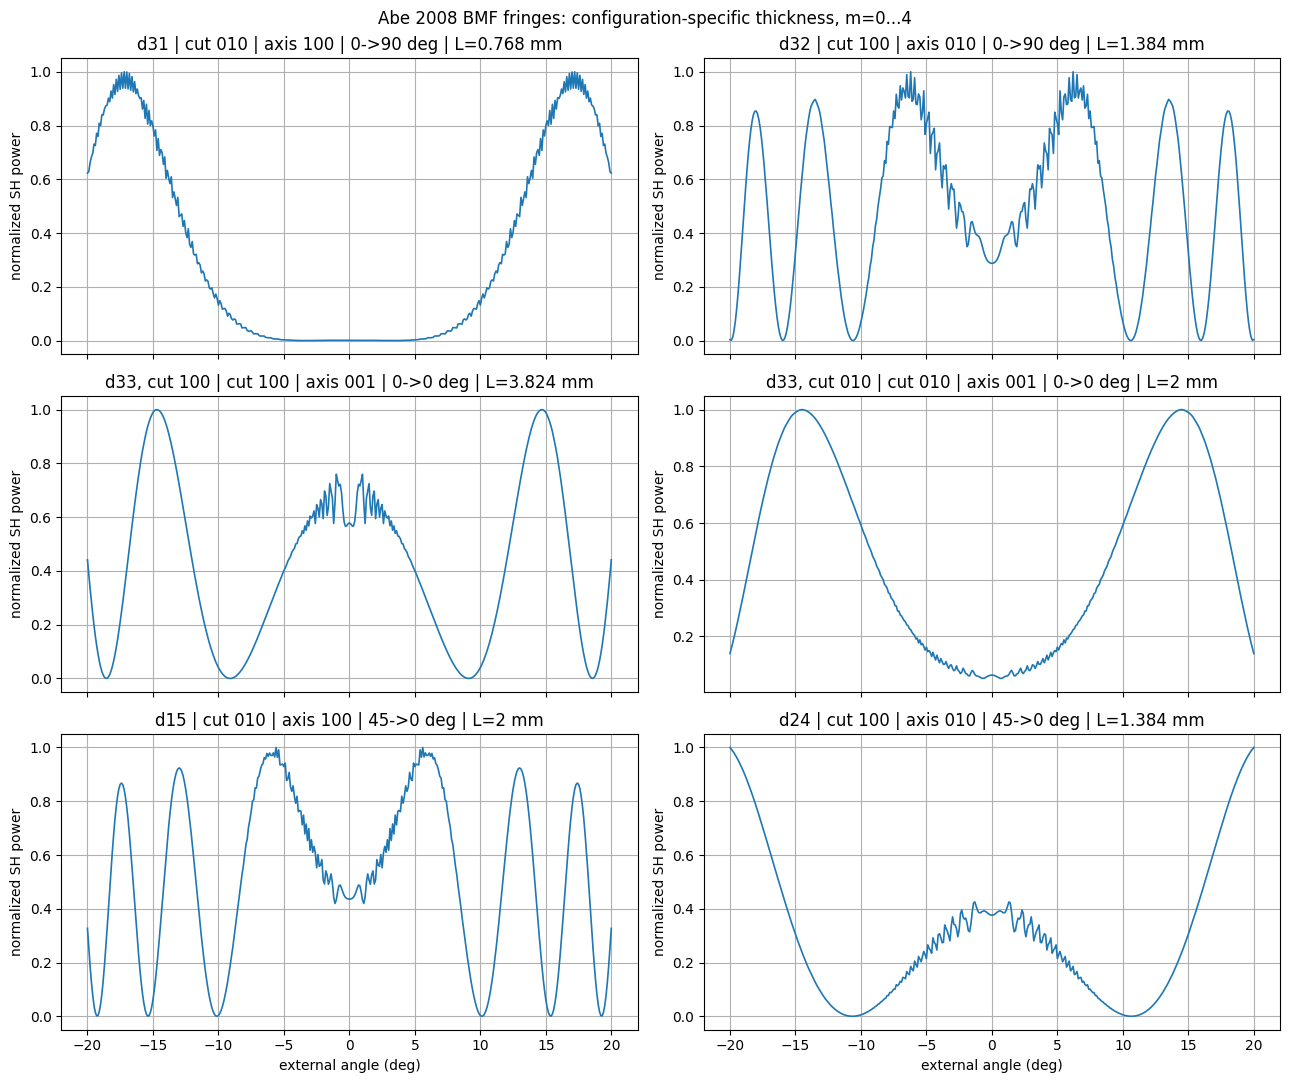

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
for ax, config in zip(axes.ravel(), BMF_CONFIGS):
    curve = abe_curves[config['label']]
    ax.plot(THETA_DEG, normalized(curve), lw=1.2)
    ax.set_title(
        f"{config['label']} | cut {config['crystal_orientation']} | axis {config['rotation_axis']} | "
        f"{config['pol_in']}->{config['pol_out']} deg | L={config['thickness_mm']:g} mm"
    )
    ax.set_ylabel('normalized SH power')
for ax in axes[-1]:
    ax.set_xlabel('external angle (deg)')
fig.suptitle(f'Abe 2008 BMF fringes: configuration-specific thickness, m=0...{MAX_M}')
fig.tight_layout()
plt.show()

## 3. Multiple reflection versus true single path

Both the fundamental and SH reflections are disabled for the single-path baseline. Each panel uses one common scale so the change in peak height remains visible.

In [10]:
single_curves = {}
started = time.perf_counter()
for config in BMF_CONFIGS:
    params = make_parameters(config, single_path=True)
    single_curves[config['label']] = Abe2008FiniteBeamModel(params).power(
        THETA_DEG, workers=WORKERS
    )
print(f'single-path calculation time: {time.perf_counter() - started:.1f} s')

single-path calculation time: 96.2 s


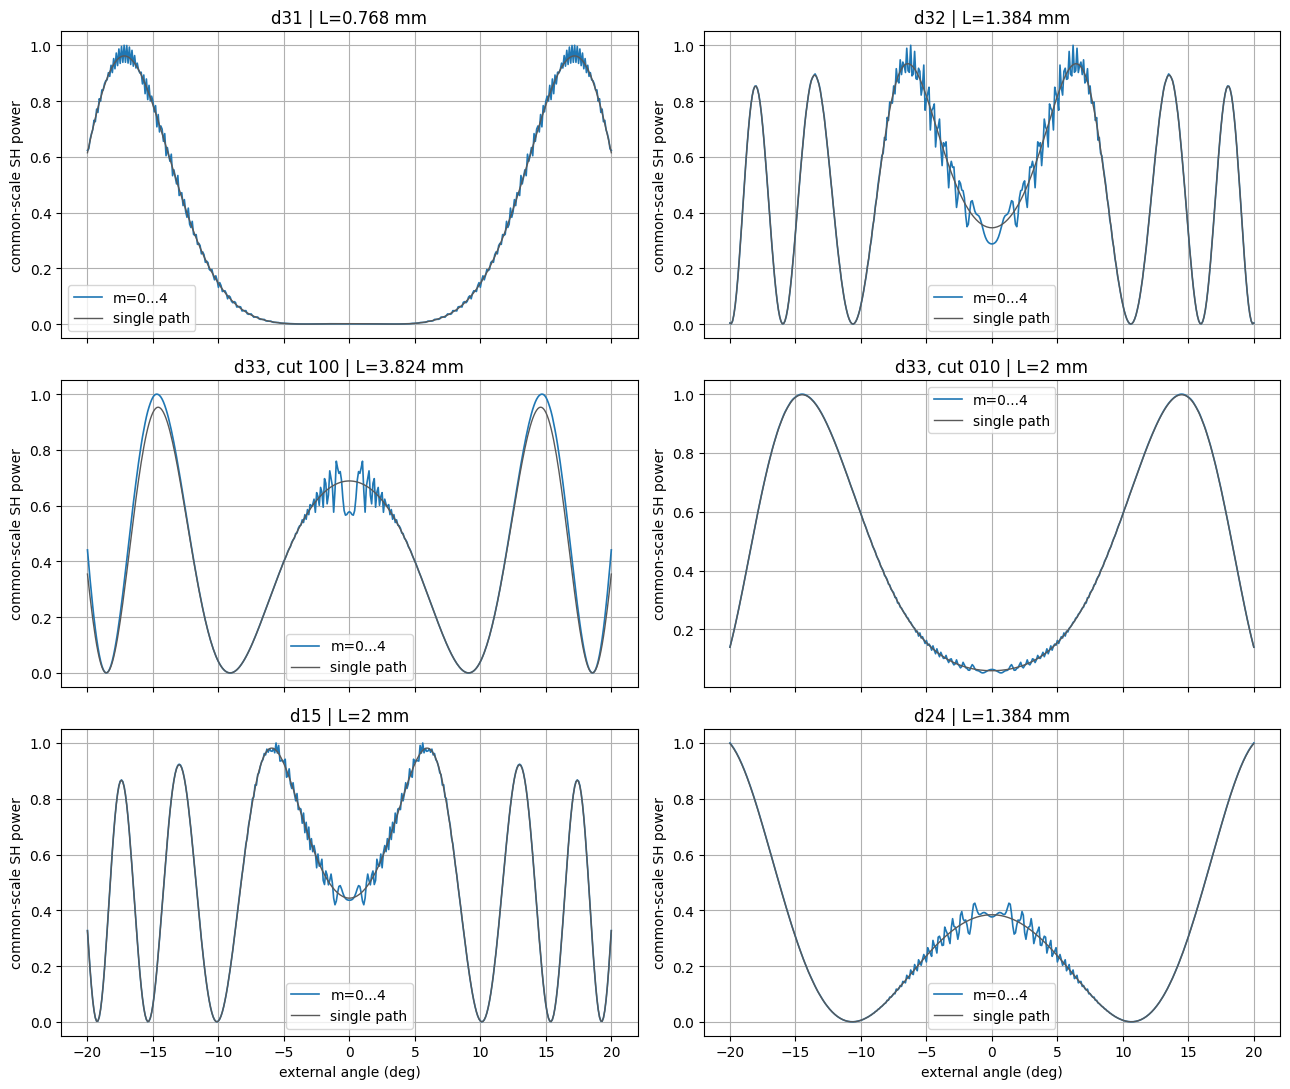

,label,thickness_mm,max_multiple,max_single,global_peak_ratio,max_robust_pointwise_ratio,symmetry_error
0,d31,0.768,1.387393e+08,1.334541e+08,1.039603,1.096363,6.770749e-13
1,d32,1.384,1.247890e+04,1.165380e+04,1.070800,1.131387,3.330445e-12
2,"d33, cut 100",3.824,2.671160e+04,2.546018e+04,1.049152,1.244528,1.146514e-11
3,"d33, cut 010",2.000,2.549661e+04,2.544325e+04,1.002097,1.210290,8.029017e-12
4,d15,2.000,1.201908e+04,1.179859e+04,1.018687,1.083110,1.110963e-11
5,d24,1.384,4.733858e+05,4.724916e+05,1.001892,1.140252,1.036279e-12


In [11]:
fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
summary = []
for ax, config in zip(axes.ravel(), BMF_CONFIGS):
    label = config['label']
    multi = abe_curves[label]
    single = single_curves[label]
    common_scale = max(np.max(multi), np.max(single))
    ax.plot(THETA_DEG, multi / common_scale, lw=1.2, label=f'm=0...{MAX_M}')
    ax.plot(THETA_DEG, single / common_scale, color='0.35', lw=1.0, label='single path')
    ax.set_title(f"{label} | L={config['thickness_mm']:g} mm")
    ax.set_ylabel('common-scale SH power')
    ax.legend()

    robust = single > 0.05 * np.max(single)
    ratios = multi[robust] / single[robust] if np.any(robust) else np.array([np.nan])
    summary.append({
        'label': label,
        'thickness_mm': config['thickness_mm'],
        'max_multiple': float(np.max(multi)),
        'max_single': float(np.max(single)),
        'global_peak_ratio': float(np.max(multi) / np.max(single)),
        'max_robust_pointwise_ratio': float(np.max(ratios)),
        'symmetry_error': float(np.max(np.abs(multi - multi[::-1])) / np.max(multi)),
    })
for ax in axes[-1]:
    ax.set_xlabel('external angle (deg)')
fig.tight_layout()
plt.show()
summary_df = pd.DataFrame(summary)
summary_df

## 4. Tensor and refractive-index routing check

This table makes the lab/crystal axis mapping explicit. It is useful when diagnosing apparently similar d31/d32 or d33 geometries that acquire different phase mismatch.

In [12]:
routing = []
for config in BMF_CONFIGS:
    p = make_parameters(config)
    routing.append({
        'label': config['label'],
        'thickness_mm': config['thickness_mm'],
        'n_w_xyz': p.n_w_xyz,
        'n_2w_xyz': p.n_2w_xyz,
        'lab_to_crystal_axes': p.lab_to_crystal_axes,
        'input_polarization': p.fundamental_polarization,
        'SH_mode': p.sh_polarization,
    })
pd.DataFrame(routing)

,label,thickness_mm,n_w_xyz,n_2w_xyz,lab_to_crystal_axes,input_polarization,SH_mode
0,d31,0.768,"(1.4600237377133243, 1.4667722906398473, 1.443...","(1.467492274998636, 1.4743657986926857, 1.4501...","(2, 0, 1)",0.0,p
1,d32,1.384,"(1.4600237377133243, 1.4431961092176886, 1.466...","(1.467492274998636, 1.4501381676744733, 1.4743...","(2, 1, 0)",0.0,p
2,"d33, cut 100",3.824,"(1.4431961092176886, 1.4600237377133243, 1.466...","(1.4501381676744733, 1.467492274998636, 1.4743...","(1, 2, 0)",0.0,s
3,"d33, cut 010",2.000,"(1.4667722906398473, 1.4600237377133243, 1.443...","(1.4743657986926857, 1.467492274998636, 1.4501...","(0, 2, 1)",0.0,s
4,d15,2.000,"(1.4600237377133243, 1.4667722906398473, 1.443...","(1.467492274998636, 1.4743657986926857, 1.4501...","(2, 0, 1)",45.0,s
5,d24,1.384,"(1.4600237377133243, 1.4431961092176886, 1.466...","(1.467492274998636, 1.4501381676744733, 1.4743...","(2, 1, 0)",45.0,s


## 5. Numerical convergence for one pure-s and one mixed-polarization geometry

In [13]:
PROBE_ANGLES = np.array([7.0, 13.0, 19.0])
convergence_rows = []
for config in [BMF_CONFIGS[0], BMF_CONFIGS[4]]:  # d31 and d15
    reference = Abe2008FiniteBeamModel(
        make_parameters(config, x_points=321, z_points=1201)
    ).power(PROBE_ANGLES, workers=3)
    for nx, nz in [(101, 401), (161, 601), (241, 801), (321, 1201)]:
        values = Abe2008FiniteBeamModel(
            make_parameters(config, x_points=nx, z_points=nz)
        ).power(PROBE_ANGLES, workers=3)
        convergence_rows.append({
            'label': config['label'],
            'x_points': nx,
            'z_points': nz,
            'max_relative_error': float(np.max(np.abs(values / reference - 1.0))),
        })
convergence_df = pd.DataFrame(convergence_rows)
convergence_df

,label,x_points,z_points,max_relative_error
0,d31,101,401,0.000180
1,d31,161,601,0.000032
2,d31,241,801,0.000010
3,d31,321,1201,0.000000
4,d15,101,401,0.056523
5,d15,161,601,0.000360
6,d15,241,801,0.000091
7,d15,321,1201,0.000000


In [14]:
default_errors = convergence_df.query('x_points == 161 and z_points == 601')
assert np.all(np.isfinite(np.concatenate(list(abe_curves.values()))))
assert np.all(summary_df['symmetry_error'] < 1e-8)
assert np.all(default_errors['max_relative_error'] < 0.02)
print('All six BMF curves are finite and symmetric; default-grid probe error is below 2%.')

All six BMF curves are finite and symmetric; default-grid probe error is below 2%.


## 6. Optional normalized comparison with Braun1997Strategy

Set the flag to `True` when comparing the finite-beam Abe calculation with the existing nonlinear 4x4 Braun model. The two models do not share an absolute normalization, so each curve is normalized independently.

In [15]:
RUN_BRAUN_COMPARISON = False

if RUN_BRAUN_COMPARISON:
    fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
    for ax, config in zip(axes.ravel(), BMF_CONFIGS):
        meta = {
            'material': 'BaMgF4',
            'wavelength_nm': WAVELENGTH_NM,
            'input_polarization': config['pol_in'],
            'detected_polarization': config['pol_out'],
            'crystal_orientation': config['crystal_orientation'],
            'rot/trans_axis': config['rotation_axis'],
            'thickness_info': {'t_center_mm': config['thickness_mm']},
            'beam_r_x': BEAM_DIAMETER_UM,
            'beam_r_y': BEAM_DIAMETER_UM,
            'd_component': config['d_component'],
        }
        data = pd.DataFrame({'position': THETA_DEG, 'intensity_corrected': np.ones_like(THETA_DEG)})
        braun = Braun1997Strategy(SimpleNamespace(meta=meta, data=data))
        braun_curve = braun._maker_fringes(override={'parallel': True})
        ax.plot(THETA_DEG, normalized(abe_curves[config['label']]), label='Abe 2008 finite beam')
        ax.plot(THETA_DEG, normalized(braun_curve), '--', label='Braun 1997 4x4')
        ax.set_title(f"{config['label']} | L={config['thickness_mm']:g} mm")
        ax.legend()
    for ax in axes[-1]:
        ax.set_xlabel('external angle (deg)')
    fig.tight_layout()
    plt.show()